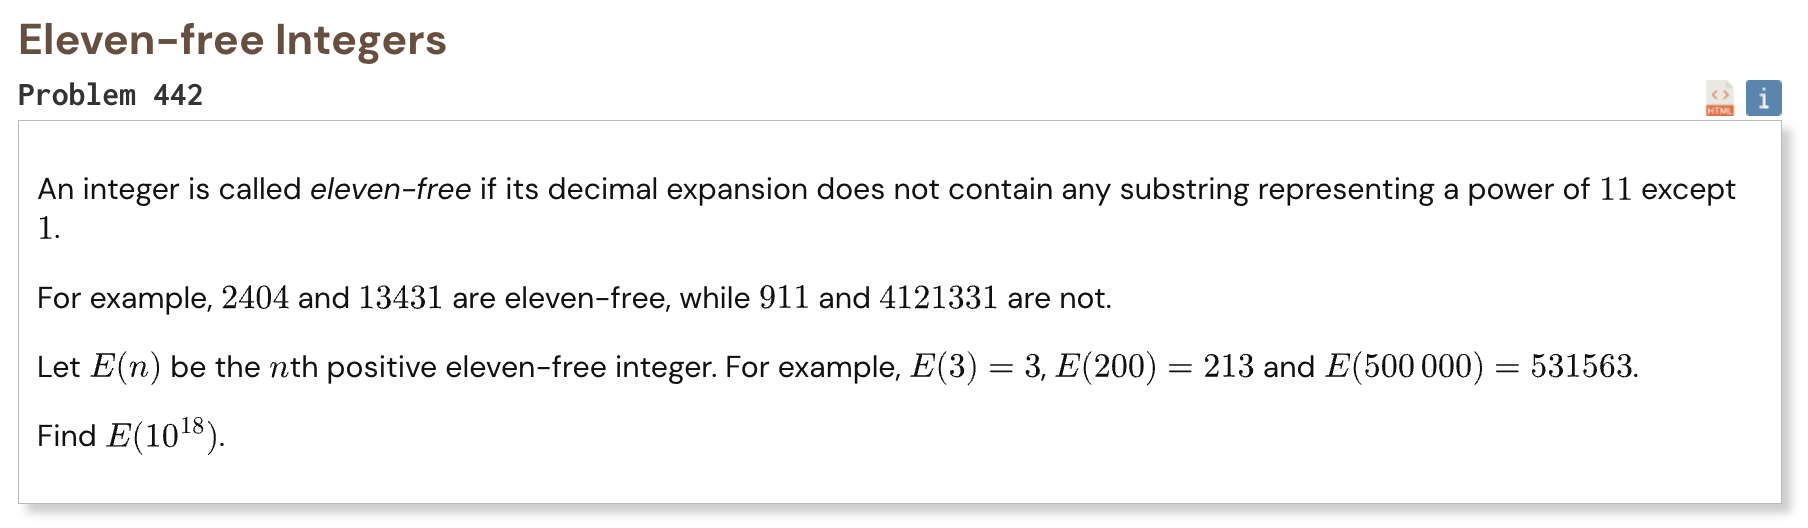

## Initial approach

-   treat every decimal form of a power of 11 except 1 as a forbidden substring
-   build one automaton that remembers whether the current digits are beginning to match any forbidden power
-   mark transitions that would complete a forbidden substring as invalid
-   use digit dynamic programming to count how many eleven-free positive integers are at most a given number
-   precompute how many valid digit suffixes can follow every automaton state
-   use the given checks such as `E(200) = 213` to verify the counting logic
-   binary search for the smallest number whose eleven-free count reaches `10^18`
-   no external library is needed

In [1]:
%%time

target = 10**18
max_digits = 40

patterns = []
value = 11

while len(str(value)) <= max_digits:
    patterns.append(str(value))
    value *= 11

next_state = [{}]
failure = [0]
blocked = [False]

for pattern in patterns:
    state = 0

    for ch in pattern:
        digit = int(ch)

        if digit not in next_state[state]:
            next_state[state][digit] = len(next_state)
            next_state.append({})
            failure.append(0)
            blocked.append(False)

        state = next_state[state][digit]

    blocked[state] = True

queue = []

for digit in range(10):
    if digit in next_state[0]:
        queue.append(next_state[0][digit])
    else:
        next_state[0][digit] = 0

index = 0

while index < len(queue):
    state = queue[index]
    index += 1

    blocked[state] = blocked[state] or blocked[failure[state]]

    for digit in range(10):
        if digit in next_state[state]:
            child = next_state[state][digit]
            failure[child] = next_state[failure[state]][digit]
            queue.append(child)
        else:
            next_state[state][digit] = next_state[failure[state]][digit]

transitions = []

for state in range(len(next_state)):
    row = []

    for digit in range(10):
        new_state = next_state[state][digit]

        if blocked[new_state]:
            row.append(-1)
        else:
            row.append(new_state)

    transitions.append(row)

state_count = len(next_state)

ways = [[0] * state_count for _ in range(max_digits + 1)]

for state in range(state_count):
    ways[0][state] = 1

for remaining in range(1, max_digits + 1):
    for state in range(state_count):
        total = 0

        for digit in range(10):
            new_state = transitions[state][digit]

            if new_state != -1:
                total += ways[remaining - 1][new_state]

        ways[remaining][state] = total

def count_eleven_free(x):
    if x <= 0:
        return 0

    digits = [int(ch) for ch in str(x)]
    length = len(digits)
    total = 0

    for size in range(1, length):
        for digit in range(1, 10):
            state = transitions[0][digit]

            if state != -1:
                total += ways[size - 1][state]

    state = 0

    for i, current_digit in enumerate(digits):
        start = 1 if i == 0 else 0

        for digit in range(start, current_digit):
            new_state = transitions[state][digit]

            if new_state != -1:
                total += ways[length - i - 1][new_state]

        state = transitions[state][current_digit]

        if state == -1:
            return total

    return total + 1

low = 1
high = 1

while count_eleven_free(high) < target:
    high *= 2

while low < high:
    mid = (low + high) // 2

    if count_eleven_free(mid) >= target:
        high = mid
    else:
        low = mid + 1

result = low

print("Result:", result)

Result: 1295552661530920149
CPU times: user 56 ms, sys: 1.78 ms, total: 57.8 ms
Wall time: 56.7 ms
